# Machine Learning Ballistic Example

Ballistics is the science of projectiles. In a general sense, a projectile is any unpowered object that is launched into the air. It could be a cannon ball, bullet, tennis ball or other object.

We will use the simplest model for ballistics which takes into account the speed and angle at which a projectile is launched, but ignores air resistances and other effects.

The objective is to launch a projectile at a certain speed to try to hit a target on the ground some distance away. 

The code below creates a function that models the trajectory for a projectile launched at a given speed and angle.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

def simple_trajectory(v0, angle_deg, g=9.81):
    # Convert angle to radians
    angle_rad = np.radians(angle_deg)
    
    # Calculate time of flight
    
    t_flight = (2 * v0 * np.sin(angle_rad)) / g
    
    # Generate time steps
    t = np.linspace(0, t_flight, num=100)
    
    # Calculate x and y positions
    x = v0 * np.cos(angle_rad) * t
    y = v0 * np.sin(angle_rad) * t - 0.5 * g * t**2

    hdist = v0 * np.cos(angle_rad) * t_flight
    # Return the trajectory of the projectile (x and y coords) and also the horizontal distance from where it lands to the origin (hdist).
    return x, y, hdist

## Part 1

Below, the code simulates launching a projectile from the origin with a speed of 30 m/s and an angle of 45 degrees.

Run the code and then change the speed to try to get the projectile to land nearer the target. If the projectile lands within 0.5 m of the target, it is considered a 'hit'.

The graph plots the trajectory of the projectile and illustrated the location of the target with an orange dot. 

Run the code below so that you understand what it does. Then answer the questions at the end.

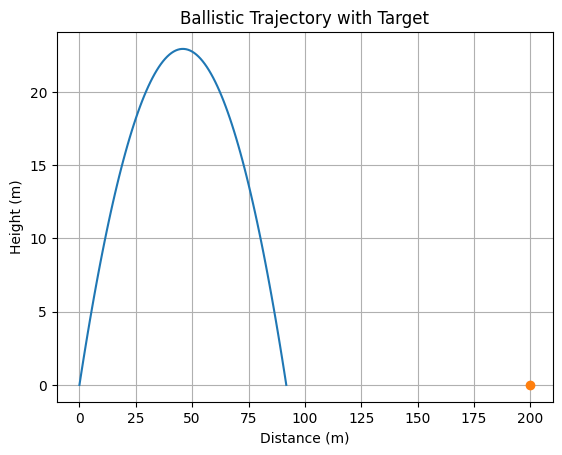

Horizontal Distance = 91.74
Target Distance = 200.00
Target missed


In [2]:
# Example: 30 m/s at a 45-degree angle with target on ground at 200m
target_hdist = 200
speed = 30
angle = 45

x_vals, y_vals, hdist = simple_trajectory(speed, angle)
plt.plot(x_vals, y_vals)
plt.plot([target_hdist], [0], 'o')
plt.title("Ballistic Trajectory with Target")
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.grid(True)
plt.show()
print(f"Horizontal Distance = {hdist:.2f}")
print(f"Target Distance = {target_hdist:.2f}")
if abs(hdist - target_hdist)<0.5:
    print("Target hit.")
else:
    print("Target missed")

## Part 1 Questions:

1. By changing the value of `speed` and running the code above repeatedly, use a process of trial-and-error to try to hit the target.
2. In the markdown cell below, state how many attempts you needed (including the first) to hit the target.
3. Describe the approach that you took.

**Type your answer to Task 2 here**

## Part 2: Machine Learning Approach

The code below follows a simple machine learning approach that we illustrated in class. It adjusts the launch speed based on the error: the difference between the target location and where the projectile lands.

First run the code below and the code cells for visualizations that come after. Then answer the questions that follow.

In [20]:
# Now run a loop to narrow in on target using machine learning principles

# Model settings
attempts = 30
target_hdist = 200
speed = 25
angle = 45
L = 0.2

speeds = []
errors = []
trajectories = []
for attempt in range(attempts):
    x_vals, y_vals, hdist = simple_trajectory(speed, angle)
    trajectories.append((x_vals, y_vals))
    speeds.append(speed)
    E = target_hdist - hdist
    print(f"Iteration: {attempt+1}")
    print(f"\tSpeed (m/s) {speed:.3f}")
    print(f"\tError (m) {E:.3f}")
    errors.append(E)
    speed = speed + L*E
    if abs(E) < 0.5:
        break


Iteration: 1
	Speed (m/s) 25.000
	Error (m) 136.290
Iteration: 2
	Speed (m/s) 52.258
	Error (m) -78.378
Iteration: 3
	Speed (m/s) 36.582
	Error (m) 63.582
Iteration: 4
	Speed (m/s) 49.299
	Error (m) -47.742
Iteration: 5
	Speed (m/s) 39.750
	Error (m) 38.932
Iteration: 6
	Speed (m/s) 47.537
	Error (m) -30.350
Iteration: 7
	Speed (m/s) 41.467
	Error (m) 24.721
Iteration: 8
	Speed (m/s) 46.411
	Error (m) -19.569
Iteration: 9
	Speed (m/s) 42.497
	Error (m) 15.902
Iteration: 10
	Speed (m/s) 45.677
	Error (m) -12.684
Iteration: 11
	Speed (m/s) 43.141
	Error (m) 10.284
Iteration: 12
	Speed (m/s) 45.197
	Error (m) -8.237
Iteration: 13
	Speed (m/s) 43.550
	Error (m) 6.666
Iteration: 14
	Speed (m/s) 44.883
	Error (m) -5.353
Iteration: 15
	Speed (m/s) 43.813
	Error (m) 4.326
Iteration: 16
	Speed (m/s) 44.678
	Error (m) -3.479
Iteration: 17
	Speed (m/s) 43.982
	Error (m) 2.809
Iteration: 18
	Speed (m/s) 44.544
	Error (m) -2.261
Iteration: 19
	Speed (m/s) 44.092
	Error (m) 1.825
Iteration: 20
	Spee

## Part 2 Visualizations

As before, we can look at how the `speed` parameter gets updated with each iteration to see how good our machine learning model is.

We can also look at the error with each iteration. Run the code cells below to see the plots of speed and error against iteration.

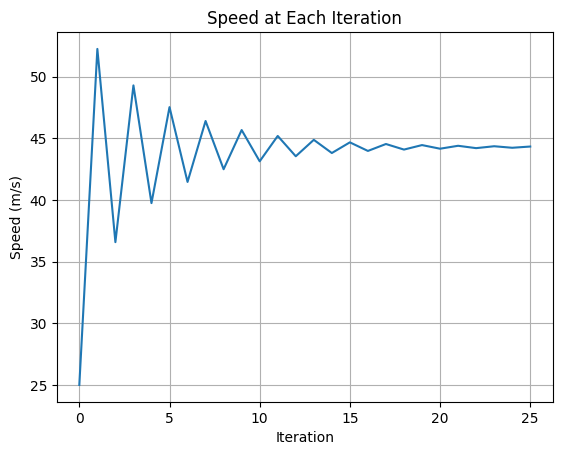

In [16]:
# Plot the sequence of speeds to see if we get convergence.
plt.plot(speeds)
plt.title("Speed at Each Iteration")
plt.ylabel("Speed (m/s)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()

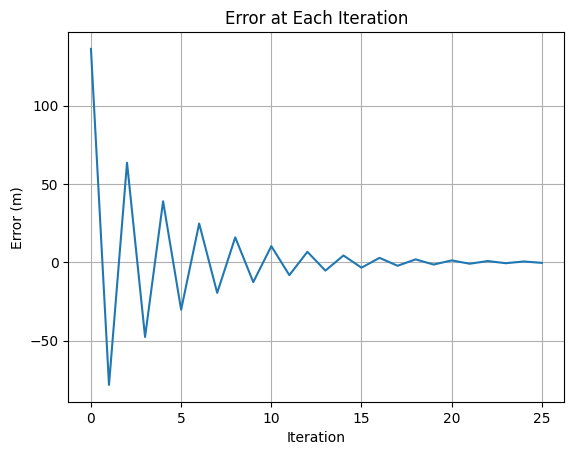

In [17]:
# Plot the sequence of errors to see if we get convergence.
plt.plot(errors)
plt.title("Error at Each Iteration")
plt.ylabel("Error (m)")
plt.xlabel("Iteration")
plt.grid(True)
plt.xticks(np.arange(0, len(speeds), 5))
plt.show()

## Part 2 Questions

Using the code in the cell above, answer the following questions.
1. With the values for attempts, speed, etc. unchanged, how many attempts does it take to get within 0.5m of the target? How far from the target does the projectile land on this last attempt?
2. Now change the learning rate to `L=0.1`. How many attempts does it take to get within 0.5m of the target? How far from the target does the projectile land on this last attempt?
3. Now change the learning rate to `L=0.01`. How many iterations are there and how close to the target does the projectile land on the last iteration?
4. Explain how the changing the learning rate seems to affect the rate at which the algorithm converges on the target.

**Type your answer to Task 2 here**

We can also visualize what is going on by seeing the trajectory of each attempt. The next two code cells illustrate how the trajectories converge on the target.

In [ ]:
# Plot all the trajectories at once
count = 1
for traj in trajectories:
    plt.plot(traj[0], traj[1])
    plt.text(traj[0][99], traj[1][99], str(count))
    count+=1
plt.show()

In [ ]:
# The code below creates an animation to illustrate the sequence of trajectories.
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

fig, ax = plt.subplots()
#x = np.linspace(0, 2*np.pi, 200)
line, = ax.plot([], [], lw=2)  # Initialize an empty line

def init():
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 75)
    return line,

def update(frame):
    x = trajectories[frame][0]
    y = trajectories[frame][1]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=attempts, init_func=init)
from IPython.display import HTML
# After creating your animation object 'ani'
HTML(ani.to_jshtml())

## Your Task

Your task is to explore how the various model parameters affect the learning.

Here is a list of all the things you can change:

1. Change the starting value of `speed`. Does the model still work if you change this?
2. Change the learning rate, `L`. For different learning rates, you may also need to change the number of attempts (iterations).
3. Change the target distance, `target_hdist`.

Here are some other changes you can try which involve more significant edits to the code.
1. Rather than adjusting the speed, what if the model adjusts the angle, but keeps the speed unchanged?
1. Add in some noise. For example, add some randomness to where the projectile lands. For example, you could use `random.gauss(0, 1)` to add noise from a normal distribution with a mean of zero and standard deviation of 1.
3. Moving target. It would be interesting to see if this model can cope with a target that is moving in a simple way, for example, if the target is moving in one direction at a constant rate afte each iteration. How could you modify the code to do this? Can the algorithm still hit the target if it is moving?

Feel free to modify the code in the previous code cells, or copy, paste and edit code in the cell below.

In [ ]:
# Put any additional code here
